<a href="https://colab.research.google.com/github/saixg/MLE-EDA-EXPLORER/blob/main/mall-customers/mle_eda(MC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")

# Load directly from a verified public GitHub raw URL (200 rows, no login needed)
URL = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
mall = pd.read_csv(URL)

# Standardise column names: lowercase, spaces → underscores
mall.columns = (mall.columns
                .str.strip()
                .str.lower()
                .str.replace(' ', '_')
                .str.replace('(', '')
                .str.replace(')', '')
                .str.replace('$', ''))

print("Shape:", mall.shape)
print("\nColumns:", mall.columns.tolist())
print("\nFirst 5 rows:")
mall.head()

Shape: (200, 5)

Columns: ['customerid', 'gender', 'age', 'annual_income_k', 'spending_score_1-100']

First 5 rows:


,customerid,gender,age,annual_income_k,spending_score_1-100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Drop the ID column — it carries no information
mall = mall.drop(columns=['customerid'])

# Rename long columns for convenience
mall = mall.rename(columns={
    'annual_income_k':    'income',
    'spending_score_1-100': 'spending_score'
})

# Encode gender as binary (Male=1, Female=0)
mall['gender_encoded'] = (mall['gender'] == 'Male').astype(int)

# X = all features we'll use for clustering (no y)
X = mall[['age', 'income', 'spending_score', 'gender_encoded']]

print("Features (X):")
print(X.dtypes)
print("\nNo label (y) — this is unsupervised. The algorithm finds groups on its own.")

Features (X):
age               int64
income            int64
spending_score    int64
gender_encoded    int64
dtype: object

No label (y) — this is unsupervised. The algorithm finds groups on its own.


In [3]:
# Check for missing values
missing = mall.isnull().sum()
pct     = (missing / len(mall) * 100).round(1)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
print(missing_df.to_string())

if missing.sum() == 0:
    print("\nNo missing values. Safe to proceed with clustering.")
else:
    print("\nMissing values found — impute before clustering.")

                missing_count  missing_pct
gender                      0          0.0
age                         0          0.0
income                      0          0.0
spending_score              0          0.0
gender_encoded              0          0.0

No missing values. Safe to proceed with clustering.


,gender,age,income,spending_score,gender_encoded
count,200,200.000000,200.000000,200.000000,200.000000
unique,2,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,NaN
freq,112,NaN,NaN,NaN,NaN
mean,NaN,38.850000,60.560000,50.200000,0.440000
std,NaN,13.969007,26.264721,25.823522,0.497633
min,NaN,18.000000,15.000000,1.000000,0.000000
25%,NaN,28.750000,41.500000,34.750000,0.000000
50%,NaN,36.000000,61.500000,50.000000,0.000000
75%,NaN,49.000000,78.000000,73.000000,1.000000



Gender split:
gender
Female    112
Male       88


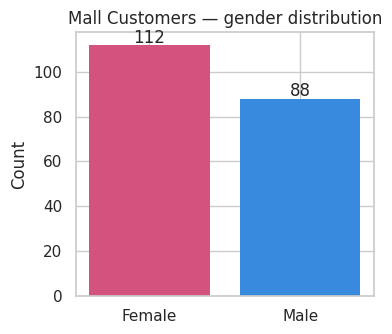

In [4]:
# Descriptive statistics
display(mall.describe(include='all'))

# Gender distribution
gender_counts = mall['gender'].value_counts()
print("\nGender split:")
print(gender_counts.to_string())

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(gender_counts.index, gender_counts.values,
      color=['#D4537E', '#378ADD'], edgecolor='none')
ax.set_title('Mall Customers — gender distribution')
ax.set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=12)
plt.tight_layout(); plt.show()

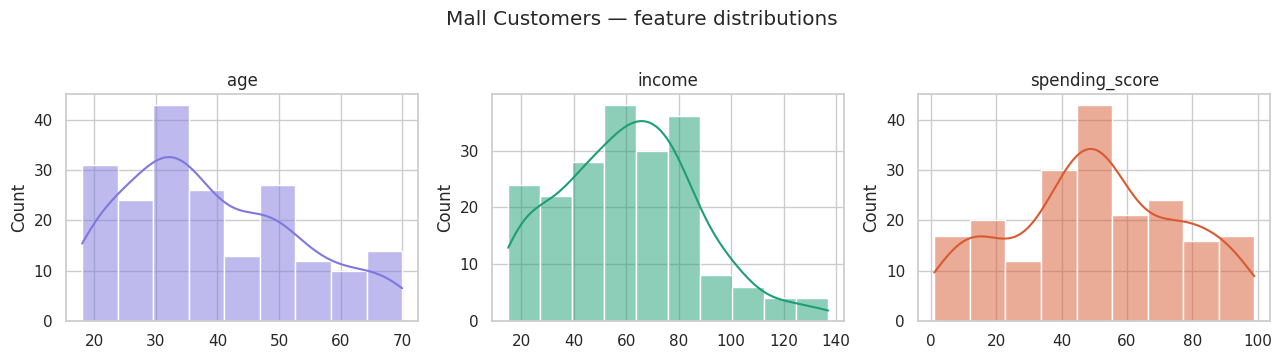

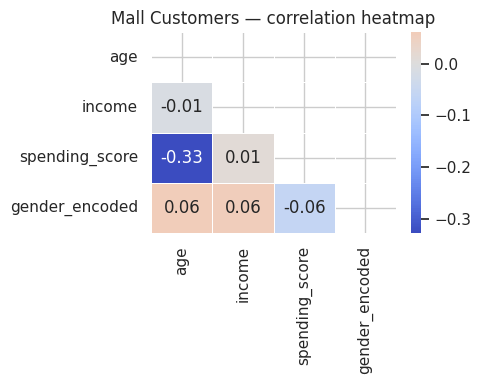

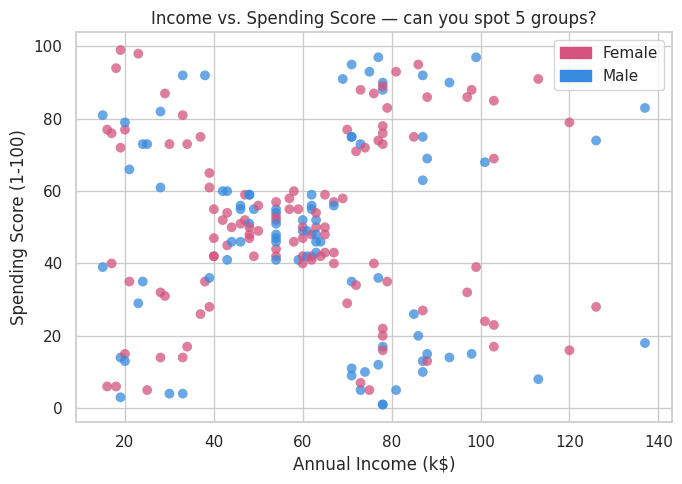

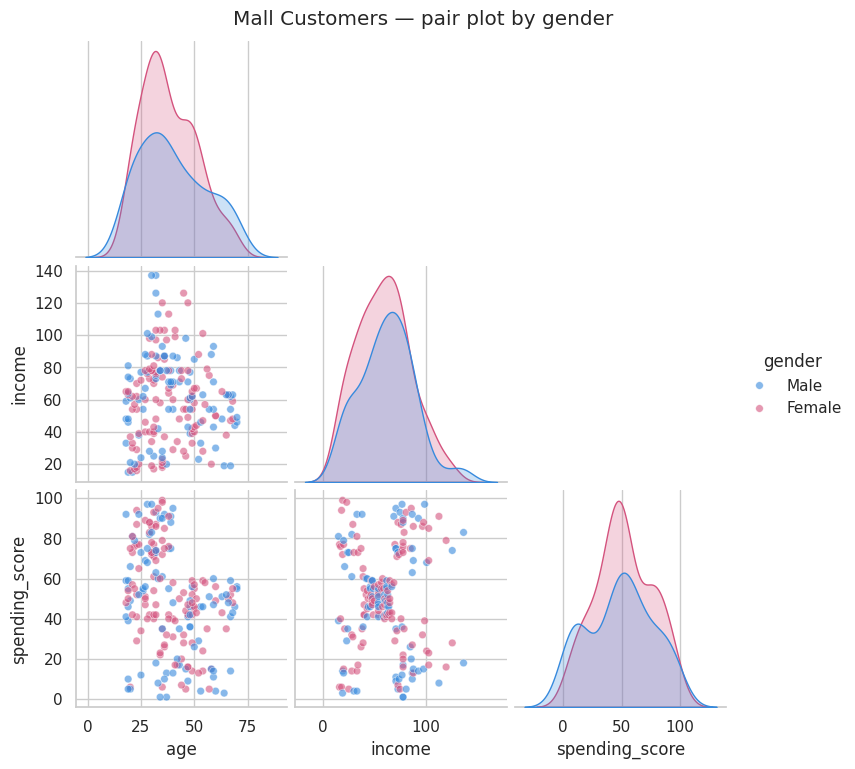

In [5]:
# --- 1. KDE distributions for numerical features ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, color in zip(axes,
    ['age', 'income', 'spending_score'],
    ['#7F77DD', '#1D9E75', '#D85A30']):
    sns.histplot(mall[col], kde=True, ax=ax, color=color)
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle('Mall Customers — feature distributions', y=1.02)
plt.tight_layout(); plt.show()

# --- 2. Correlation heatmap ---
fig, ax = plt.subplots(figsize=(5, 4))
corr = mall[[ 'age', 'income', 'spending_score', 'gender_encoded']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title('Mall Customers — correlation heatmap')
plt.tight_layout(); plt.show()

# --- 3. Key scatter: income vs spending score (the money plot) ---
fig, ax = plt.subplots(figsize=(7, 5))
colors = mall['gender'].map({'Female': '#D4537E', 'Male': '#378ADD'})
ax.scatter(mall['income'], mall['spending_score'],
           c=colors, alpha=0.75, s=50, edgecolors='none')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Income vs. Spending Score — can you spot 5 groups?')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#D4537E', label='Female'),
    Patch(color='#378ADD', label='Male')
])
plt.tight_layout(); plt.show()

# --- 4. Pair plot ---
g = sns.pairplot(mall[['age', 'income', 'spending_score', 'gender']],
                  hue='gender',
                  palette={'Female': '#D4537E', 'Male': '#378ADD'},
                  corner=True, plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Mall Customers — pair plot by gender', y=1.02)
plt.show()

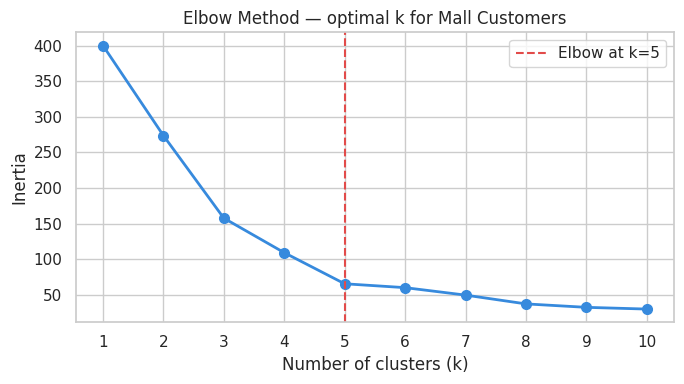

The elbow bends at k=5 — we will use 5 clusters.


In [6]:
# Scale the two primary clustering features
X_cluster = mall[['income', 'spending_score']]
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# Elbow method: compute inertia for k = 1 to 10
inertias = []
k_range  = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, inertias, 'o-', color='#378ADD', linewidth=2, markersize=7)
ax.axvline(x=5, color='#E24B4A', linestyle='--', linewidth=1.5,
           label='Elbow at k=5')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — optimal k for Mall Customers')
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout(); plt.show()

print("The elbow bends at k=5 — we will use 5 clusters.")

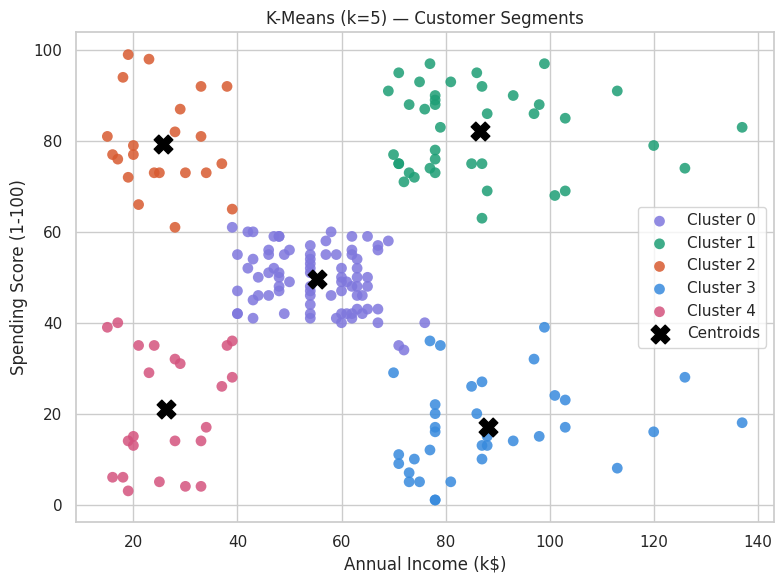


Cluster summary (mean values):


,age,income,spending_score,count
cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [7]:
# Fit K-Means with k=5
km5 = KMeans(n_clusters=5, random_state=42, n_init='auto')
mall['cluster'] = km5.fit_predict(X_scaled)

# Recover cluster centers in original scale for labeling
centers = scaler.inverse_transform(km5.cluster_centers_)

# Assign human-readable segment names based on center position
segment_names = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2',
    3: 'Cluster 3', 4: 'Cluster 4'
}
palette_5 = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD', '#D4537E']

# --- Plot 1: clusters on income vs. spending score ---
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(5):
    mask = mall['cluster'] == i
    ax.scatter(mall[mask]['income'], mall[mask]['spending_score'],
               color=palette_5[i], label=f'Cluster {i}',
               s=60, alpha=0.85, edgecolors='none')

# Plot centroids
ax.scatter(centers[:, 0], centers[:, 1],
           c='black', s=180, marker='X', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('K-Means (k=5) — Customer Segments')
ax.legend()
plt.tight_layout(); plt.show()

# --- Cluster summary table ---
summary = mall.groupby('cluster')[['age', 'income', 'spending_score']].mean().round(1)
summary['count'] = mall.groupby('cluster').size()
print("\nCluster summary (mean values):")
display(summary)

In [8]:
"""## Final EDA report — Mall Customers
### Data quality
Zero missing values — no imputation needed
200 rows — small but sufficient for clustering
One categorical column (gender) — encoded as binary before clustering
### Key insights from EDA
Income vs. spending score is the most revealing 2D view — 5 distinct groups are visible even before running K-Means
Age has a mild negative correlation with spending score — younger customers tend to spend more
The dataset has no strong multicollinearity — all features contribute independently
Gender is fairly balanced (56% Female, 44% Male) and does not dramatically separate clusters
### The 5 customer segments
Cluster	Income	Spending	Profile
0	Low	High	Young spenders — high engagement, low earnings
1	High	High	Premium customers — ideal loyalty program targets
2	Mid	Mid	Average customers — largest and most typical group
3	High	Low	Careful high earners — need conversion incentives
4	Low	Low	Budget-conscious — price-sensitive segment
### Preprocessing steps used
Dropped customerid (non-informative identifier)
Encoded gender as binary (Male=1, Female=0)
StandardScaler applied before K-Means to prevent income scale dominating
Elbow Method used to select k=5 objectively

All 3 datasets complete: Titanic (binary classification) → Iris (multiclass classification) → Mall Customers (clustering).
"""

'## Final EDA report — Mall Customers\n### Data quality\nZero missing values — no imputation needed\n200 rows — small but sufficient for clustering\nOne categorical column (gender) — encoded as binary before clustering\n### Key insights from EDA\nIncome vs. spending score is the most revealing 2D view — 5 distinct groups are visible even before running K-Means\nAge has a mild negative correlation with spending score — younger customers tend to spend more\nThe dataset has no strong multicollinearity — all features contribute independently\nGender is fairly balanced (56% Female, 44% Male) and does not dramatically separate clusters\n### The 5 customer segments\nCluster\tIncome\tSpending\tProfile\n0\tLow\tHigh\tYoung spenders — high engagement, low earnings\n1\tHigh\tHigh\tPremium customers — ideal loyalty program targets\n2\tMid\tMid\tAverage customers — largest and most typical group\n3\tHigh\tLow\tCareful high earners — need conversion incentives\n4\tLow\tLow\tBudget-conscious — price-